In [1]:
import pandas as pd
import numpy as np 
import os
import pdfplumber
import rbert as rb

df = pd.read_csv("books.csv")
df

C:\Users\dima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,path,id
0,books\22.1.pdf,22.100
1,books\22.12.pdf,22.120
2,books\22.123.pdf,22.123
3,books\22.124.pdf,22.124
4,books\22.126.pdf,22.126
...,...,...
259,books\28.68.pdf,28.680
260,books\28.69.pdf,28.690
261,books\28.7.pdf,28.700
262,books\28.706.pdf,28.706


In [2]:
def extract_text( pdf_path, start_page=0):
    """Извлечение текста из PDF с обработкой ошибок"""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            text_pages = []
            for i, page in enumerate(pdf.pages[start_page:], start=start_page):
                text = page.extract_text()
                if text:
                    text_pages.append(text)
            result = " ".join(text_pages) if text_pages else ""
            return result
    except Exception as e:
        return ""

In [3]:
with open("../web/res.txt", 'r') as f:
    s = f.read().split(' ')[0]
s

'24.811'

In [4]:
import os
import random

books_dir = 'books'

# Выводим путь к папке 'books'
print(books_dir)
random.seed(42)
files = [f for f in os.listdir(books_dir) if os.path.isfile(os.path.join(books_dir, f))]
random.shuffle(files)  # Перемешиваем файлы случайным образом
  # Создаём список с путями

books


In [5]:
print(files)

files2 = [os.path.join('books', f) for f in files]

['24.54.pdf', '28.66.pdf', '28.46.pdf', '26.233.pdf', '22.127.pdf', '28.1.pdf', '28.5.pdf', '28.14.pdf', '22.134.pdf', '24.591.pdf', '28.4.pdf', '22.353.pdf', '28.71.pdf', '28.089.pdf', '26.820.pdf', '28.4(2).pdf', '24.2(2).pdf', '24.581.pdf', '26.82.pdf', '28.53.pdf', '24.632.pdf', '26.89.pdf', '24.542.pdf', '22.68.pdf', '22.655.pdf', '22.2.pdf', '24.574.pdf', '22.655(2).pdf', '26.11.pdf', '24.117.pdf', '28.45.pdf', '22.124.pdf', '28.57.pdf', '24.614.pdf', '26.823.pdf', '26.21.pdf', '28.48.pdf', '24.511.pdf', '26.219.pdf', '26.31.pdf', '22.126.pdf', '24.212.pdf', '22.146.pdf', '24.1(2).pdf', '22.612.pdf', '24.133.pdf', '24.622.pdf', '24.631.pdf', '26.322.pdf', '22.33.pdf', '28.071.pdf', '28.43.pdf', '22.341(2).pdf', '24.63.pdf', '28.65.pdf', '28.083.pdf', '28.69.pdf', '24.573.pdf', '26.314.pdf', '22.195(2).pdf', '24.45.pdf', '24.51.pdf', '24.73.pdf', '28.7.pdf', '22.172.pdf', '22.61.pdf', '26.23.pdf', '28.42.pdf', '26.190.pdf', '24.118.pdf', '26.34.pdf', '22.135.pdf', '26.38.pdf', '28

In [6]:
i = 0
cur = []
pred = []
for f1, f2 in zip(files, files2):
    if i == 20: break
    print(f"Анализ для {i} документа {f1}")
    processor = rb.DocumentProcessor()
    print(processor.model_name)
    book_text = extract_text(f2)
    processor.analyze_document(book_text)
    
    cur.append(f1)
    
    with open("../web/res.txt", 'r', encoding='utf-8') as f:
        s = f.read().split(' ')[0]
        pred.append(s)
        print(f"Правильный индекс: {f1}, Предсказанный индекс: {s}")
        
    with open("../web/res.txt", 'w') as f:
        pass
    i+=1

sberbert = pd.DataFrame({'train': cur, 'pred': pred})
sberbert.to_csv("sberai.csv")

Анализ для 0 документа 24.54.pdf


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

deepvk/RuModernBERT-base


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

Правильный индекс: 24.54.pdf, Предсказанный индекс: 22.161
Анализ для 1 документа 28.66.pdf
deepvk/RuModernBERT-base
Правильный индекс: 28.66.pdf, Предсказанный индекс: 22.192
Анализ для 2 документа 28.46.pdf


...

Правильный индекс: 26.82.pdf, Предсказанный индекс: 26.303
Анализ для 19 документа 28.53.pdf


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

deepvk/RuModernBERT-base


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

Правильный индекс: 28.53.pdf, Предсказанный индекс: 24.811


In [97]:
modernbert = pd.DataFrame({'train': cur, 'pred': pred})
modernbert

,train,pred
0,22.312.pdf,22.632
1,26.8.pdf,<br><br>26.305
2,26.80.pdf,24.210
3,24.5.pdf,<br><br>24.434
4,22.18(2).pdf,22.192
5,26.212.pdf,22.632
6,22.345.pdf,22.632
7,26.34.pdf,26.324
8,24.553.pdf,24.434
9,24.4.pdf,24.434


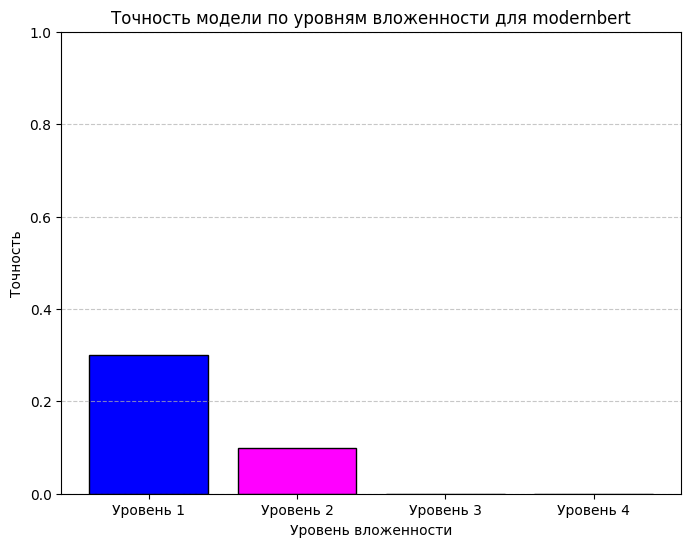

Точность по уровням: [0.3, 0.1, 0.0, 0.0]

Результаты по текстам:
    text  level_1  level_2  level_3  level_4
0      1        0        0      0.0      NaN
1      2        0        0      0.0      NaN
2      3        0        0      0.0      NaN
3      4        1        0      0.0      0.0
4      5        0        0      NaN      NaN
5      6        0        0      NaN      NaN
6      7        0        0      NaN      NaN
7      8        0        0      0.0      NaN
8      9        1        1      0.0      0.0
9     10        1        0      0.0      0.0
10    11        0        0      NaN      NaN
11    12        1        0      0.0      0.0
12    13        0        0      0.0      NaN
13    14        0        0      0.0      0.0
14    15        0        0      0.0      NaN
15    16        0        0      NaN      NaN
16    17        1        1      NaN      NaN
17    18        0        0      0.0      0.0
18    19        1        0      0.0      NaN
19    20        0        0      0.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("sberai.csv")

# Функция для извлечения уровней вложенности
def get_levels(number):
    str_num = str(number)
    integer_part = str_num.split('.')[0]
    try:
        decimal_part = str_num.split('.')[1]
    except IndexError:
        decimal_part = ''
    
    levels = [integer_part]
    for i in range(1, min(4, len(decimal_part) + 1)):
        levels.append(integer_part + '.' + decimal_part[:i])
    return levels

# Проверка совпадений на каждом уровне
results = []
for idx, row in df.iterrows():
    train_levels = get_levels(row['train'])
    pred_levels = get_levels(row['pred'])
    text_result = {'text': idx + 1}
    for level in range(1, 5):
        if level <= len(train_levels) and level <= len(pred_levels):
            is_correct = train_levels[level - 1] == pred_levels[level - 1]
            text_result[f'level_{level}'] = 1 if is_correct else 0
        else:
            text_result[f'level_{level}'] = None
    results.append(text_result)

results_df = pd.DataFrame(results)

# Подсчет средней точности по уровням
accuracy = []
for level in range(1, 5):
    level_col = f'level_{level}'
    valid_results = results_df[level_col].dropna()
    acc = valid_results.mean() if len(valid_results) > 0 else 0
    accuracy.append(acc)

# Построение графика
plt.figure(figsize=(8, 6))
plt.bar(range(1, 5), accuracy, color=['#0000FF', '#FF00FF', '#00FF00', '#FF1493'], edgecolor='black')
plt.xlabel('Уровень вложенности')
plt.ylabel('Точность')
plt.title('Точность модели по уровням вложенности для modernbert')
plt.xticks(range(1, 5), ['Уровень 1', 'Уровень 2', 'Уровень 3', 'Уровень 4'])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Вывод результатов
print("Точность по уровням:", accuracy)
print("\nРезультаты по текстам:")
print(results_df)

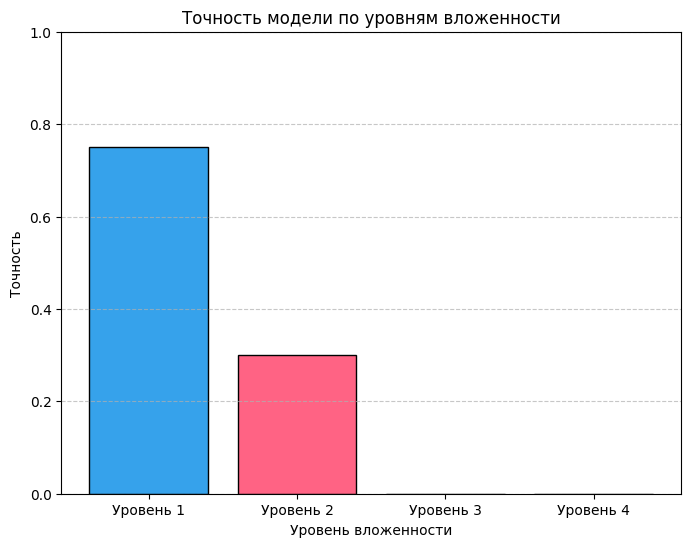

Точность по уровням: [0.75, 0.3, 0.0, 0.0]

Результаты по текстам:
    text  level_1  level_2  level_3  level_4
0      1        1        0      0.0      0.0
1      2        1        0      NaN      NaN
2      3        0        0      NaN      NaN
3      4        1        0      NaN      NaN
4      5        1        1      0.0      NaN
5      6        0        0      0.0      0.0
6      7        1        0      0.0      0.0
7      8        1        1      0.0      NaN
8      9        1        0      0.0      0.0
9     10        1        1      NaN      NaN
10    11        1        0      0.0      NaN
11    12        1        0      0.0      0.0
12    13        1        0      0.0      0.0
13    14        0        0      0.0      NaN
14    15        1        1      0.0      NaN
15    16        0        0      0.0      0.0
16    17        0        0      0.0      0.0
17    18        1        1      0.0      NaN
18    19        1        1      NaN      NaN
19    20        1        0      0

In [105]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("sberai.csv")

# Функция для извлечения уровней вложенности
def get_levels(number):
    str_num = str(number)
    integer_part = str_num.split('.')[0]
    try:
        decimal_part = str_num.split('.')[1]
    except IndexError:
        decimal_part = ''
    
    levels = [integer_part]
    for i in range(1, min(4, len(decimal_part) + 1)):
        levels.append(integer_part + '.' + decimal_part[:i])
    return levels

# Проверка совпадений на каждом уровне
results = []
for idx, row in df.iterrows():
    train_levels = get_levels(row['train'])
    pred_levels = get_levels(row['pred'])
    text_result = {'text': idx + 1}
    for level in range(1, 5):
        if level <= len(train_levels) and level <= len(pred_levels):
            is_correct = train_levels[level - 1] == pred_levels[level - 1]
            text_result[f'level_{level}'] = 1 if is_correct else 0
        else:
            text_result[f'level_{level}'] = None
    results.append(text_result)

results_df = pd.DataFrame(results)

# Подсчет средней точности по уровням
accuracy = []
for level in range(1, 5):
    level_col = f'level_{level}'
    valid_results = results_df[level_col].dropna()
    acc = valid_results.mean() if len(valid_results) > 0 else 0
    accuracy.append(acc)

# Построение графика
plt.figure(figsize=(8, 6))
plt.bar(range(1, 5), accuracy, color=['#36A2EB', '#FF6384', '#FFCE56', '#4BC0C0'], edgecolor='black')
plt.xlabel('Уровень вложенности')
plt.ylabel('Точность')
plt.title('Точность модели по уровням вложенности')
plt.xticks(range(1, 5), ['Уровень 1', 'Уровень 2', 'Уровень 3', 'Уровень 4'])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Вывод результатов
print("Точность по уровням:", accuracy)
print("\nРезультаты по текстам:")
print(results_df)

In [ ]:
        # with open('..\\web\\res.txt', 'w') as f:
        #     f.write('')

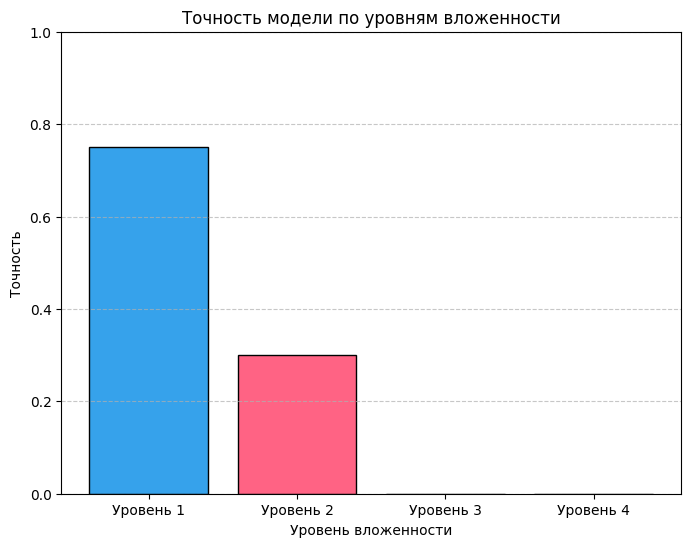

Точность по уровням: [0.75, 0.3, 0.0, 0.0]

Результаты по текстам:
    text  level_1  level_2  level_3  level_4
0      1        1        0      0.0      0.0
1      2        1        0      NaN      NaN
2      3        0        0      NaN      NaN
3      4        1        0      NaN      NaN
4      5        1        1      0.0      NaN
5      6        0        0      0.0      0.0
6      7        1        0      0.0      0.0
7      8        1        1      0.0      NaN
8      9        1        0      0.0      0.0
9     10        1        1      NaN      NaN
10    11        1        0      0.0      NaN
11    12        1        0      0.0      0.0
12    13        1        0      0.0      0.0
13    14        0        0      0.0      NaN
14    15        1        1      0.0      NaN
15    16        0        0      0.0      0.0
16    17        0        0      0.0      0.0
17    18        1        1      0.0      NaN
18    19        1        1      NaN      NaN
19    20        1        0      0

In [106]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("sberai.csv")

# Функция для извлечения уровней вложенности
def get_levels(number):
    str_num = str(number)
    integer_part = str_num.split('.')[0]
    try:
        decimal_part = str_num.split('.')[1]
    except IndexError:
        decimal_part = ''
    
    levels = [integer_part]
    for i in range(1, min(4, len(decimal_part) + 1)):
        levels.append(integer_part + '.' + decimal_part[:i])
    return levels

# Проверка совпадений на каждом уровне
results = []
for idx, row in df.iterrows():
    train_levels = get_levels(row['train'])
    pred_levels = get_levels(row['pred'])
    text_result = {'text': idx + 1}
    for level in range(1, 5):
        if level <= len(train_levels) and level <= len(pred_levels):
            is_correct = train_levels[level - 1] == pred_levels[level - 1]
            text_result[f'level_{level}'] = 1 if is_correct else 0
        else:
            text_result[f'level_{level}'] = None
    results.append(text_result)

results_df = pd.DataFrame(results)

# Подсчет средней точности по уровням
accuracy = []
for level in range(1, 5):
    level_col = f'level_{level}'
    valid_results = results_df[level_col].dropna()
    acc = valid_results.mean() if len(valid_results) > 0 else 0
    accuracy.append(acc)

# Построение графика
plt.figure(figsize=(8, 6))
plt.bar(range(1, 5), accuracy, color=['#36A2EB', '#FF6384', '#FFCE56', '#4BC0C0'], edgecolor='black')
plt.xlabel('Уровень вложенности')
plt.ylabel('Точность')
plt.title('Точность модели по уровням вложенности')
plt.xticks(range(1, 5), ['Уровень 1', 'Уровень 2', 'Уровень 3', 'Уровень 4'])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Вывод результатов
print("Точность по уровням:", accuracy)
print("\nРезультаты по текстам:")
print(results_df)

In [ ]:
# if __name__ == '__main__':
#     text = extract_text("books\\22.123.pdf")
#     processor = DocumentProcessor()
#     pr = processor.analyze_document(text)